# Predicted vs gold trajectories: aggregate arcs survive classifier error, single dialogues do not

日本語要約: ノートブック 01 の分類器（マクロ F1 約 0.39）の予測ラベルで
ノートブック 02 の軌跡分析を再実行し、正解ラベルの結果と突き合わせる。
これがこのリポジトリの核心で、「不完全な分類器の出力を時系列集計しても
何が信用できるか」を定量化する。結果: コーパス全体の平均アークは形状が
ほぼ保存される（アーク相関 > 0.9、ただし感情の過剰予測により水準は上振れ）
一方、個々の会話の軌跡は中央値相関 0.7 程度で、約 1 割の会話では負の相関になる。
結論は「集計ダッシュボードには使える、個別会話の自動診断には使えない」。

**What this notebook shows**

- The full pipeline run honestly end to end: train the classifier on the
  train split, predict emotions on held-out dialogues, build trajectories
  from those predictions, and compare against gold-label trajectories.
- Two ways to feed predictions into valence: hard argmax labels, and the
  probability-weighted expected valence from `predict_proba`.
- Aggregate arc comparison: the predicted arc tracks the gold arc's shape
  closely (correlation asserted above 0.8; about 0.98 on the committed
  full-corpus run) but overestimates its level, and the notebook explains
  why.
- Per-dialogue comparison: the distribution of correlations between
  predicted and gold smoothed valence series, with its long left tail
  shown rather than summarized away.
- A concrete trustworthiness statement for VoC practice, backed by the
  numbers above.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from voc_arc.classifier import build_model, evaluate
from voc_arc.data import load_dataset, split_dialogues
from voc_arc.plotting import PALETTE, plot_arc_band, set_style
from voc_arc.trajectory import (
    aggregate_arc,
    dialogue_valences,
    ewma,
    expected_valence,
)

set_style()
SEED = 42
CI = bool(os.environ.get("CI"))
N_BOOT = 100 if CI else 500
EWMA_ALPHA = 0.4

df, source = load_dataset()
print(f"source={source}, n_boot={N_BOOT}")

source=raw, n_boot=500


## 1. Train on train dialogues, predict on test dialogues

Same split as notebook 01 (dialogue-level, seed 42), so the classifier
never saw any turn of the conversations it is now asked to trace.

In [2]:
train, test = split_dialogues(df, test_size=0.2, seed=SEED)
model = build_model(seed=SEED).fit(train["text"].tolist(), train["emotion"].to_numpy())

test = test.sort_values(["dialogue_id", "turn"]).reset_index(drop=True)
proba = model.predict_proba(test["text"].tolist())
test["predicted"] = model.classes_[np.argmax(proba, axis=1)]
test["expected_valence"] = expected_valence(proba)

scores = evaluate(test["emotion"].to_numpy(), test["predicted"].to_numpy())
print(
    f"test dialogues: {test['dialogue_id'].nunique()}, "
    f"utterance macro-F1: {scores['macro_f1']:.3f}"
)

test dialogues: 2623, utterance macro-F1: 0.390


## 2. Aggregate arc: shape preserved, level inflated

Three arcs over the same test dialogues: gold labels, hard predicted
labels, and expected valence (probability-weighted, which keeps
low-confidence utterances near zero instead of snapping them to +-1).

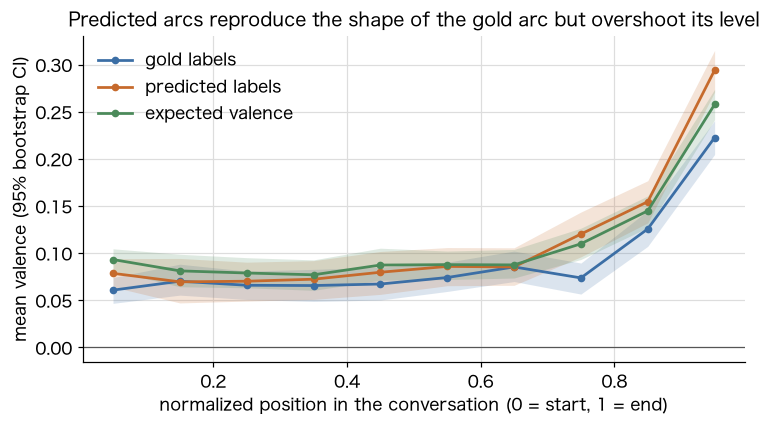

In [3]:
gold_arcs = dialogue_valences(test, "emotion")
pred_arcs = dialogue_valences(test, "predicted")
grouped = test.groupby("dialogue_id", sort=True)
ev_arcs = [group["expected_valence"].to_numpy() for _, group in grouped]

arc_gold = aggregate_arc(gold_arcs, n_bins=10, n_boot=N_BOOT, seed=SEED)
arc_pred = aggregate_arc(pred_arcs, n_bins=10, n_boot=N_BOOT, seed=SEED)
arc_ev = aggregate_arc(ev_arcs, n_bins=10, n_boot=N_BOOT, seed=SEED)

plot_arc_band(
    {"gold labels": arc_gold, "predicted labels": arc_pred, "expected valence": arc_ev},
    title="Predicted arcs reproduce the shape of the gold arc but overshoot its level",
)
plt.tight_layout()

In [4]:
arc_comparison = pd.DataFrame(
    {
        "position": arc_gold["position"],
        "gold": arc_gold["mean"],
        "predicted": arc_pred["mean"],
        "expected_valence": arc_ev["mean"],
    }
)
arc_corr = float(np.corrcoef(arc_gold["mean"], arc_pred["mean"])[0, 1])
level_bias = float((arc_pred["mean"] - arc_gold["mean"]).mean())
arc_comparison.round(4)

,position,gold,predicted,expected_valence
0,0.05,0.0608,0.0786,0.0932
1,0.15,0.0702,0.0696,0.0812
2,0.25,0.0660,0.0702,0.0790
3,0.35,0.0657,0.0724,0.0771
4,0.45,0.0673,0.0798,0.0874
5,0.55,0.0742,0.0859,0.0878
6,0.65,0.0854,0.0854,0.0876
7,0.75,0.0738,0.1203,0.1100
8,0.85,0.1257,0.1546,0.1449
9,0.95,0.2226,0.2942,0.2578


## 3. Numeric validation of the aggregate claim

In [5]:
assert arc_corr > 0.8, f"arc shape correlation too low: {arc_corr:.3f}"
assert level_bias > 0, "expected the documented positive level bias"
print(f"arc correlation (gold vs predicted): {arc_corr:.3f}, mean level bias: +{level_bias:.4f}")

arc correlation (gold vs predicted): 0.980, mean level bias: +0.0199


On the committed full-corpus run the correlation is about 0.98: the
flat-then-rising shape, including the end-of-conversation spike, comes
through classifier error essentially intact. The systematic part of the
error is the level: predicted arcs sit above gold everywhere. The cause
is visible in notebook 01's confusion matrix. Balanced class weights make
the model over-predict emotion classes relative to their true base rates,
and since happiness dominates the emotion mass, over-predicted emotion is
mostly over-predicted positive valence. An aggregate VoC dashboard built
on this pipeline should therefore be read for shape and trend, and
calibrated (or baselined against its own history) before absolute levels
are quoted.

## 4. Per-dialogue trajectories: the long left tail

The same comparison at the level where a practitioner would want to use
it: one conversation at a time. For every test dialogue with at least
four turns and non-constant series on both sides, correlate the smoothed
gold valence with the smoothed expected valence.

In [6]:
correlations = []
for gold, predicted in zip(gold_arcs, ev_arcs, strict=True):
    if len(gold) < 4:
        continue
    gold_smooth = ewma(gold, alpha=EWMA_ALPHA)
    pred_smooth = ewma(predicted, alpha=EWMA_ALPHA)
    if gold_smooth.std() == 0 or pred_smooth.std() == 0:
        continue
    correlations.append(float(np.corrcoef(gold_smooth, pred_smooth)[0, 1]))
correlations = np.array(correlations)

median_corr = float(np.median(correlations))
share_negative = float((correlations < 0).mean())
assert median_corr > 0.5, f"median per-dialogue correlation too low: {median_corr:.3f}"
print(
    f"dialogues compared: {len(correlations)}, median correlation: {median_corr:.3f}, "
    f"negative correlation share: {share_negative:.1%}"
)

dialogues compared: 1118, median correlation: 0.731, negative correlation share: 10.0%


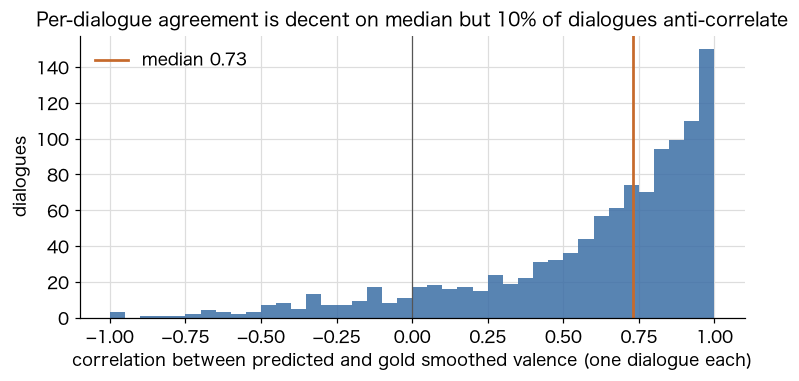

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(correlations, bins=np.linspace(-1, 1, 41), color=PALETTE[0], alpha=0.85)
ax.axvline(median_corr, color=PALETTE[1], lw=1.8, label=f"median {median_corr:.2f}")
ax.axvline(0, color="#555555", lw=0.8)
ax.set_xlabel("correlation between predicted and gold smoothed valence (one dialogue each)")
ax.set_ylabel("dialogues")
ax.set_title(
    f"Per-dialogue agreement is decent on median but {share_negative:.0%} of "
    "dialogues anti-correlate"
)
ax.legend(frameon=False)
plt.tight_layout()

## 5. What agreement and failure look like

One dialogue from the top of the correlation distribution and one from
the bottom (among dialogues with a clear emotional signal), gold and
predicted overlaid.

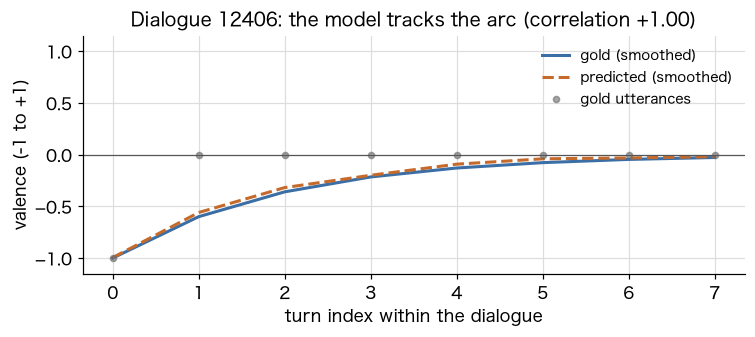

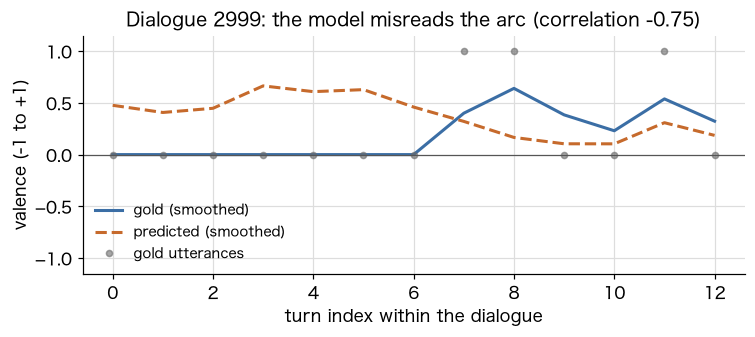

In [8]:
detailed = []
for (dialogue_id, _group), gold, predicted in zip(grouped, gold_arcs, ev_arcs, strict=True):
    if len(gold) < 8 or gold.std() < 0.3:
        continue
    gold_smooth = ewma(gold, alpha=EWMA_ALPHA)
    pred_smooth = ewma(predicted, alpha=EWMA_ALPHA)
    if gold_smooth.std() == 0 or pred_smooth.std() == 0:
        continue
    corr = float(np.corrcoef(gold_smooth, pred_smooth)[0, 1])
    detailed.append((corr, dialogue_id, gold, predicted))
detailed.sort(key=lambda item: item[0])

for corr, dialogue_id, gold, predicted in (detailed[-1], detailed[0]):
    verdict = "tracks" if corr > 0.5 else "misreads"
    fig, ax = plt.subplots(figsize=(7, 3.2))
    turns = np.arange(len(gold))
    ax.plot(turns, ewma(gold, EWMA_ALPHA), "-", color=PALETTE[0], lw=2.0, label="gold (smoothed)")
    ax.plot(
        turns,
        ewma(predicted, EWMA_ALPHA),
        "--",
        color=PALETTE[1],
        lw=2.0,
        label="predicted (smoothed)",
    )
    ax.plot(turns, gold, "o", color=PALETTE[5], ms=4, alpha=0.6, label="gold utterances")
    ax.axhline(0, color="#555555", lw=0.8)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xlabel("turn index within the dialogue")
    ax.set_ylabel("valence (-1 to +1)")
    ax.set_title(f"Dialogue {dialogue_id}: the model {verdict} the arc (correlation {corr:+.2f})")
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()

The failure cases are systematic rather than random. Dialogues that
anti-correlate typically hinge on emotions the classifier cannot detect
(notebook 01: fear and disgust F1 near zero) or on polite phrasing of
negative content ("I am afraid that is the best we can do" reads as
neutral-to-positive to a lexical model). Exactly the utterances whose
misreading flips a trajectory are the ones a bag-of-ngrams model is
worst at.

## 6. When to trust this pipeline

| Use case | Verdict | Basis |
|---|---|---|
| Corpus-level arc shape and trend monitoring | usable | arc correlation about 0.98 (full run), shape preserved |
| Absolute valence levels | calibrate first | consistent positive bias from over-predicted emotion |
| Ranking dialogues for review queues | usable with care | median per-dialogue correlation about 0.7 orders most dialogues sensibly |
| Automated single-dialogue diagnosis | not with this classifier | about one in ten dialogues anti-correlates with its own gold arc |

## Limitations

- All conclusions inherit the valence mapping and the scripted-dialogue
  caveats of notebook 02, plus the classifier weaknesses of notebook 01;
  this notebook quantifies their interaction, it does not remove them.
- Gold labels are the yardstick here, but they are single-annotator
  labels; some "classifier errors" are plausibly annotation noise.
- The per-dialogue correlation excludes constant-valence dialogues, so it
  describes emotionally active conversations, not the full corpus.
- A stronger encoder would raise per-utterance F1 and presumably the
  per-dialogue numbers; the aggregate-vs-individual gap should shrink but
  not vanish. That comparison is future work, deliberately out of scope
  for a dependency-light reference implementation.

## References

- Li, Su, Shen, Li, Cao, Niu. "DailyDialog: A Manually Labelled Multi-turn
  Dialogue Dataset." IJCNLP 2017.